BEFORE MinMaxScaler (original values):

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0   8.325      41.0     6.984      1.024       322.0     2.556     37.88   
1   8.301      21.0     6.238      0.972      2401.0     2.110     37.86   
2   7.257      52.0     8.288      1.073       496.0     2.802     37.85   
3   5.643      52.0     5.817      1.073       558.0     2.548     37.85   
4   3.846      52.0     6.282      1.081       565.0     2.181     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

           MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    1425.477      3.071   
std        1.900     12.586      2.474      0.474    1132.462     10.386   
min        0.500      1.000      0.846      0.333       3.000      0.692   
25%        2.563     18.000    

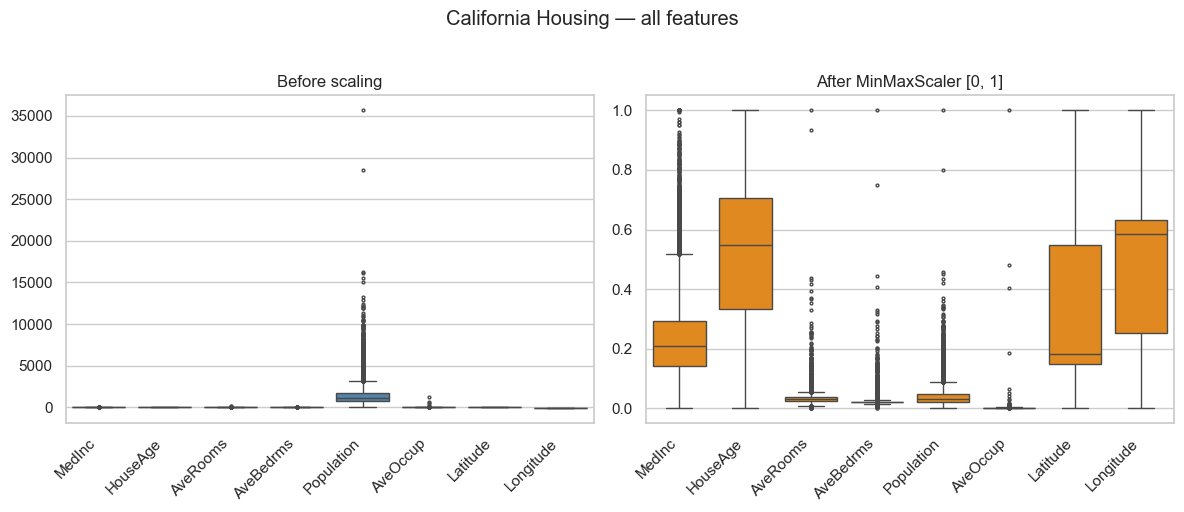

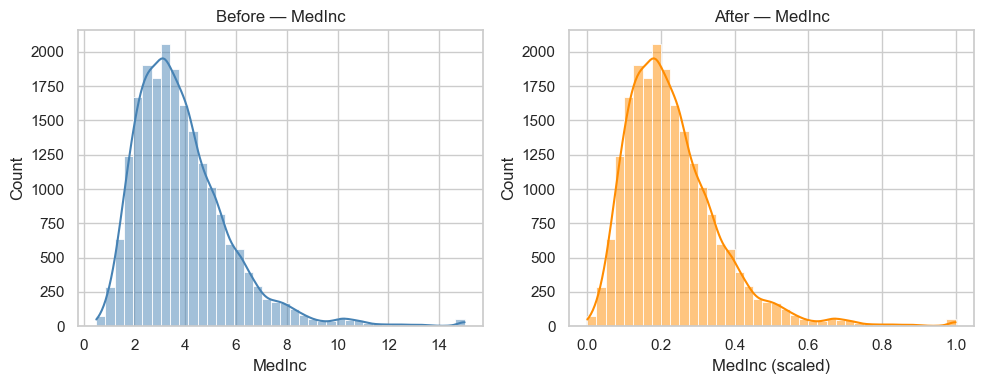


Takeaway: every feature is rescaled to the same [0, 1] range.
  x_scaled = (x - column_min) / (column_max - column_min)


In [ ]:
# MinMaxScaler on California Housing — before vs after
# Formula: x_scaled = (x - min) / (max - min)  ->  values land in [0, 1]
# In Jupyter: add `%matplotlib inline` at the top for inline charts.
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


# 1. Load features
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
print("BEFORE MinMaxScaler (original values):\n")
print(X.head().round(3))
print("\n", X.describe().round(3))


# 2. Fit MinMaxScaler and transform
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
)
print("\n" + "=" * 50)
print("AFTER MinMaxScaler (scaled to [0, 1]):\n")
print(X_scaled.head().round(3))
print("\n", X_scaled.describe().round(3))



# 3. Worked example — one feature, first 5 rows
feature = "MedInc"
lo = scaler.data_min_[X.columns.get_loc(feature)]
hi = scaler.data_max_[X.columns.get_loc(feature)]
example = pd.DataFrame({
    "raw": X[feature].head(),
    "min": lo,
    "max": hi,
})
example["scaled = (raw - min) / (max - min)"] = (
    (example["raw"] - example["min"]) / (example["max"] - example["min"])
).round(3)
example["sklearn output"] = X_scaled[feature].head().round(3).values
print("\n" + "=" * 50)
print(f"How scaling works for {feature}:\n")
print(example.to_string())


# 4. Quick before / after summary
print("\n" + "=" * 50)
print("Before vs after (min and max per feature):\n")
comparison = pd.DataFrame({
    "before_min": X.min(),
    "before_max": X.max(),
    "after_min": X_scaled.min(),
    "after_max": X_scaled.max(),
}).round(3)
print(comparison.to_string())


# 5. Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=X, ax=axes[0], color="steelblue", fliersize=2)
axes[0].set_title("Before scaling")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
sns.boxplot(data=X_scaled, ax=axes[1], color="darkorange", fliersize=2)
axes[1].set_title("After MinMaxScaler [0, 1]")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
plt.suptitle("California Housing — all features", y=1.02)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(X[feature], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"Before — {feature}")
axes[0].set_xlabel(feature)
sns.histplot(X_scaled[feature], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title(f"After — {feature}")
axes[1].set_xlabel(f"{feature} (scaled)")
plt.tight_layout()
plt.show()
print("\nTakeaway: every feature is rescaled to the same [0, 1] range.")
print("  x_scaled = (x - column_min) / (column_max - column_min)")
